# Predictive Maintenance - Machine Temperature Anomaly Detection

## Objective
Detect abnormal machine behavior using time-series temperature data.

## Step 1
Load dataset and visualize temperature trend.

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

#Load dataset directly from Github
url = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/machine_temperature_system_failure.csv"
df = pd.read_csv(url)
df.head()

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  22695 non-null  object 
 1   value      22695 non-null  float64
dtypes: float64(1), object(1)
memory usage: 354.7+ KB


,value
count,22695.000000
mean,85.926498
std,13.746912
min,2.084721
25%,83.080078
50%,89.408246
75%,94.016252
max,108.510543


In [4]:
# Convert timestamp to datetime

df['timestamp'] = pd.to_datetime(df['timestamp'])

In [5]:
# Checking datatypes after changing the datatype
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  22695 non-null  datetime64[ns]
 1   value      22695 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 354.7 KB


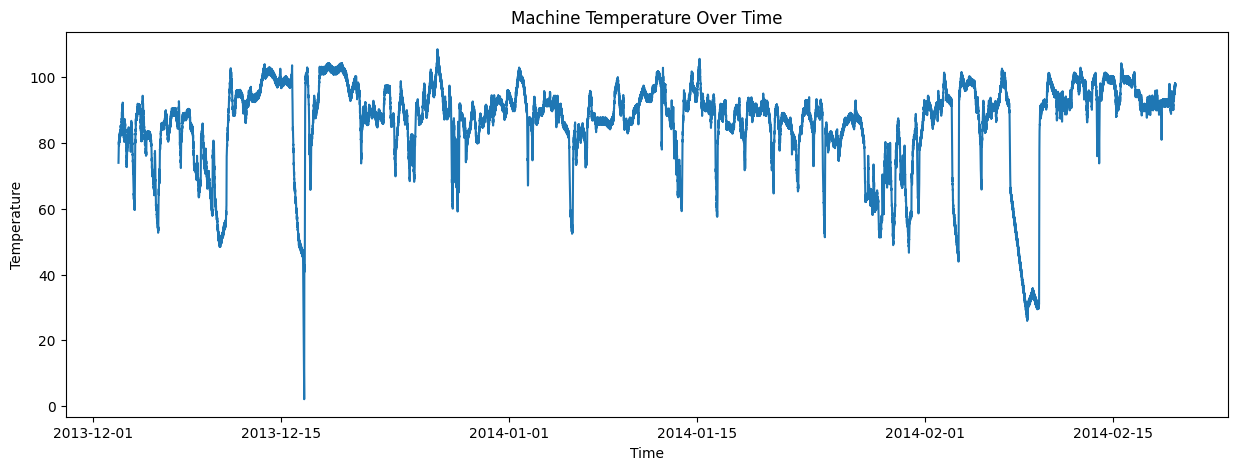

In [6]:
#Visualizing data
plt.figure(figsize=(15,5))
plt.plot(df['timestamp'],df['value'])
plt.title('Machine Temperature Over Time')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.show()

In [15]:
# setting timestamp as index
df.set_index('timestamp',inplace=True)
df.head()

,value
timestamp,
2013-12-02 21:15:00,73.967322
2013-12-02 21:20:00,74.935882
2013-12-02 21:25:00,76.124162
2013-12-02 21:30:00,78.140707
2013-12-02 21:35:00,79.329836


In [17]:
df.index.value_counts()[df.index.value_counts()>1]

,count
timestamp,
2014-01-07 02:55:00,2
2014-01-07 02:50:00,2
2014-01-07 02:45:00,2
2014-01-07 02:40:00,2
2014-01-07 02:35:00,2
2014-01-07 02:30:00,2
2014-01-07 02:25:00,2
2014-01-07 02:20:00,2
2014-01-07 02:15:00,2


In [24]:
# Remove Duplicates
df = df.groupby(level=0).mean()

In [25]:
# Basic statistics
mean = df['value'].mean()
std = df['value'].std()

print(f"Mean temperature:{mean:.2f}")
print(f"Standard Deviation:{std:.2f}")

Mean temperature:85.92
Standard Deviation:13.75


## Adding Rolling mean

After overlaying Rolling mean on the original Temperature. We are seperating two things.
1. Short Time Fluctation(noise): The Original Temperature Line
2. Underlying trend: The rolling mean line

In [26]:
# Adding Rolling mean
df['rolling_mean'] = df['value'].rolling(window=50).mean()

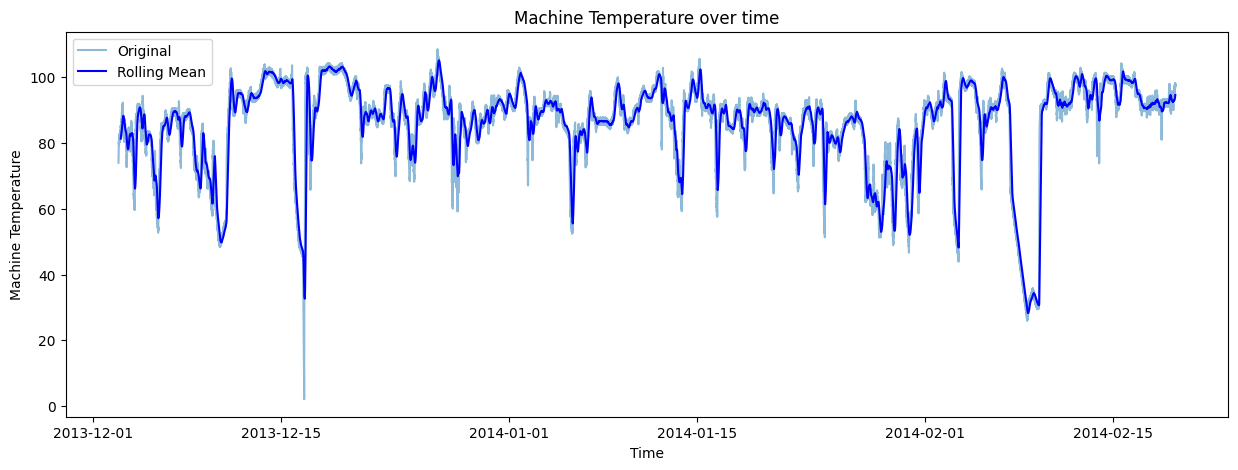

In [27]:
plt.figure(figsize=(15,5))
plt.plot(df.index,df['value'],alpha=0.5,label='Original')
plt.plot(df.index,df['rolling_mean'],label='Rolling Mean',color = 'b')
plt.legend()
plt.title('Machine Temperature over time')
plt.xlabel('Time')
plt.ylabel('Machine Temperature')
plt.show()

## Observation
During **normal operation** temperature shows random flactuation around a stable baseline.

**Event/Failure behaviour:** The system shows gradual shift in machine temperature , indicating abnormal machine behaviour.

## Statistical Threshold method
we use the 3 sigma rule to detect anomalies in machine temperature
Any value outside mean + 3 standard deviation value is marked as an anamoly.



In [28]:
# Calcaluating upper and lower limit
mean_temp = df['value'].mean()
std_temp = df['value'].std()

upper_limit = mean_temp + 3 * std_temp
lower_limit = mean_temp - 3 * std_temp

upper_limit,lower_limit

(np.float64(127.17015819617694), np.float64(44.6743597426232))

In [30]:
# Adding limit columns to dataframe
df['upper_limit'] = upper_limit
df['lower_limit'] = lower_limit

In [31]:
# Detect anomalies

df['anomaly'] = ((df['value'] > df['upper_limit']) | (df['value']<df['lower_limit']))

In [32]:
# Extract only anomalies
anomalies = df[df['anomaly']==True]
anomalies.head()

,value,rolling_mean,upper_limit,lower_limit,anomaly
timestamp,,,,,
2013-12-16 15:25:00,43.177455,46.859075,127.170158,44.67436,True
2013-12-16 15:30:00,41.308989,46.743834,127.170158,44.67436,True
2013-12-16 15:35:00,40.461427,46.603406,127.170158,44.67436,True
2013-12-16 15:40:00,37.791275,46.416193,127.170158,44.67436,True
2013-12-16 15:45:00,36.249653,46.181740,127.170158,44.67436,True


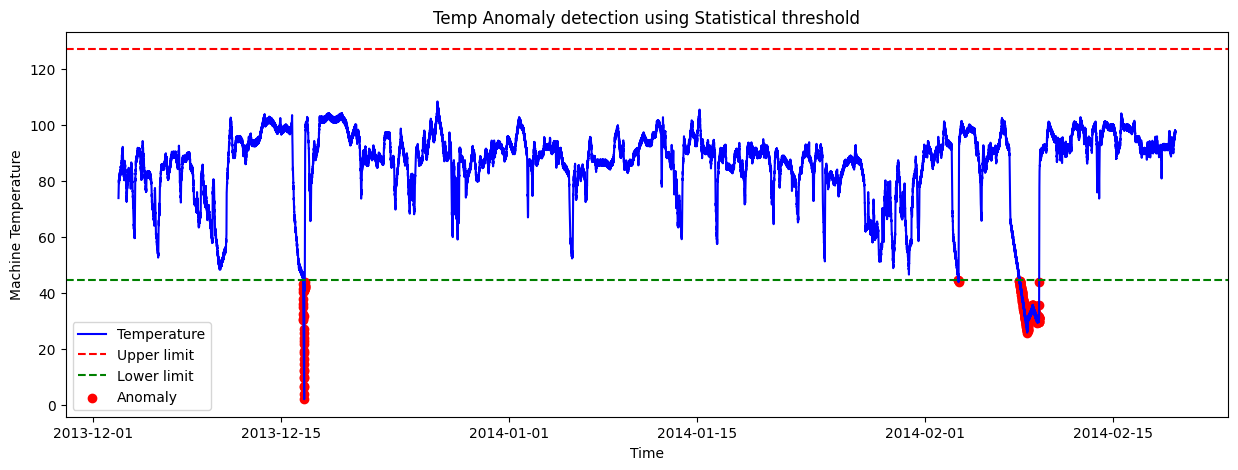

In [33]:
#Visualize the treshold
plt.figure(figsize=(15,5))
plt.plot(df.index,df['value'],color='b',label='Temperature')

plt.axhline(upper_limit,color='r',linestyle = '--',label='Upper limit')
plt.axhline(lower_limit,color='g',linestyle = '--',label='Lower limit')
plt.scatter(anomalies.index,anomalies['value'],color='r',label='Anomaly')

plt.xlabel('Time')
plt.ylabel('Machine Temperature')
plt.legend()
plt.title('Temp Anomaly detection using Statistical threshold')
plt.show()

## Calculate rolling mean and standard deviation

In [34]:
window = 50
rolling_mean = df['value'].rolling(window=window).mean()
rolling_std = df['value'].rolling(window=window).std()
df['rolling_mean'] = rolling_mean
df['rolling_std'] = rolling_std

## Creating rolling threshold

In [35]:
df['upper_limit_rolling'] = rolling_mean + 3*rolling_std
df['lower_limit_rolling'] = rolling_mean - 3*rolling_std

## Detecting rolling anomalies

In [36]:
df['anomal_rolling'] = (df['value']>df['upper_limit_rolling'])|(df['value']<df['upper_limit_rolling'])

## Extracting Anomalies

In [37]:
anomal_rolling = df[df['anomal_rolling']==True]
anomal_rolling.head()

,value,rolling_mean,upper_limit,lower_limit,anomaly,rolling_std,upper_limit_rolling,lower_limit_rolling,anomal_rolling
timestamp,,,,,,,,,
2013-12-03 01:20:00,85.344624,81.307319,127.170158,44.67436,False,2.262449,88.094666,74.519972,True
2013-12-03 01:25:00,84.671962,81.521412,127.170158,44.67436,False,2.050229,87.672100,75.370724,True
2013-12-03 01:30:00,85.302762,81.728749,127.170158,44.67436,False,1.888464,87.394142,76.063357,True
2013-12-03 01:35:00,84.349211,81.893250,127.170158,44.67436,False,1.742921,87.122014,76.664487,True
2013-12-03 01:40:00,84.555844,82.021553,127.170158,44.67436,False,1.696549,87.111201,76.931906,True


## Plot Rolling Detection

In [38]:
df_zoom = df.iloc[3000:5000]
anomal_rolling_zoom = anomal_rolling.iloc[30000:50000]

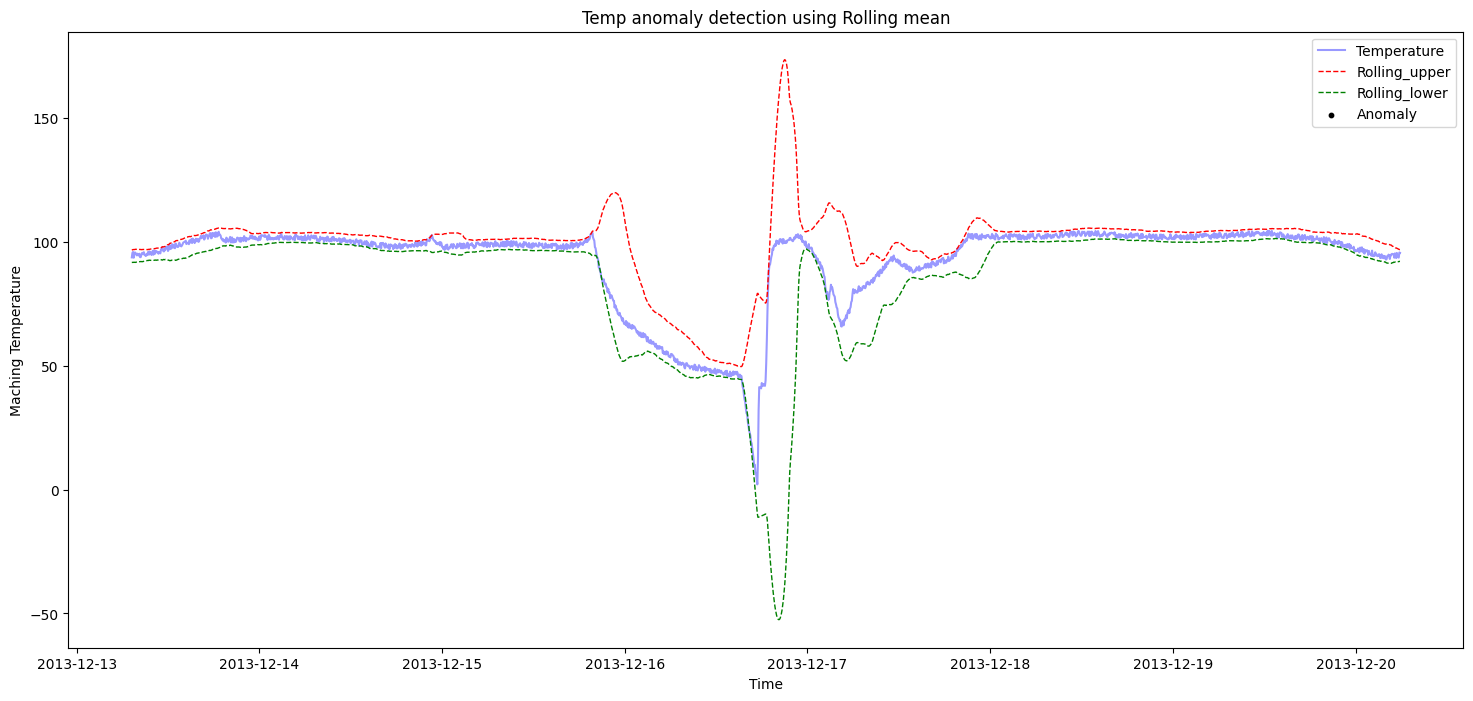

In [39]:
plt.figure(figsize=(18,8))
plt.plot(df_zoom.index,df_zoom['value'],color='b',alpha=0.4,label='Temperature')

plt.plot(df_zoom.index,df_zoom['upper_limit_rolling'],color='red',linewidth=1,linestyle = '--',label='Rolling_upper')
plt.plot(df_zoom.index,df_zoom['lower_limit_rolling'],color='green',linewidth=1,linestyle='--',label='Rolling_lower')

plt.scatter(anomal_rolling_zoom.index,anomal_rolling_zoom['value'],s=10,color='black',label='Anomaly')

plt.legend()
plt.xlabel('Time')
plt.ylabel('Maching Temperature')
plt.title('Temp anomaly detection using Rolling mean')
plt.show()

## Observation
Rolling threshold adopts to local behaviour of time series. However, large spikes within rolling window expands increases the rolling standard deviation, which expands the threshold and may prevent those spikes from being flagged as anomalies.

## Isolation Forest Anomaly detection

Isolation Forest Anomaly detection detects anomalies by isolating observations through random partitioning. Points that require fewer splits to isolate are considered anomalies

Unlike statistical threshold methods, Isolation forest does not assume a specific distribution and can detect both the spikes and gradual drift patterns in the data.

In [40]:
from sklearn.ensemble import IsolationForest

In [41]:
# Isolationforest requires feature matrix
features = df[['value','rolling_mean','rolling_std']].dropna()

In [42]:
features.head(5)

,value,rolling_mean,rolling_std
timestamp,,,
2013-12-03 01:20:00,85.344624,81.307319,2.262449
2013-12-03 01:25:00,84.671962,81.521412,2.050229
2013-12-03 01:30:00,85.302762,81.728749,1.888464
2013-12-03 01:35:00,84.349211,81.893250,1.742921
2013-12-03 01:40:00,84.555844,82.021553,1.696549


In [43]:
# Train the Isolation forest method
model = IsolationForest(n_estimators=100,contamination=0.05,random_state=42)
model.fit(features)

IsolationForest(contamination=0.05, random_state=42)

In [44]:
#Predict Anomalies
features['anomaly_iforest']=model.predict(features)

In [45]:
#Extract Anomalies
anomalies_Iforest = features[features['anomaly_iforest']==-1]

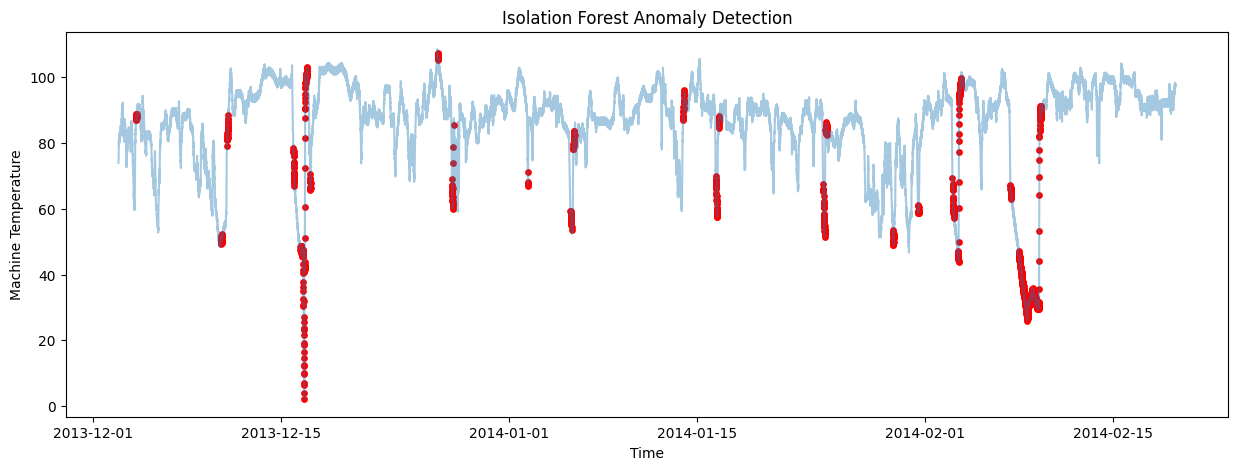

In [46]:
#Plot Isolation Forestresult
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df.index,df['value'],alpha=0.4,label='Temperature')
plt.scatter(anomalies_Iforest.index,anomalies_Iforest['value'],color='red',s=15,label='Isolation Forest Anomaly')

plt.title('Isolation Forest Anomaly Detection')
plt.xlabel('Time')
plt.ylabel('Machine Temperature')
plt.legend
plt.show()

Isolation Forest successfully detects point anomalies such as sudden spikes or drops in temperature. However, gradual drift patterns are not detected effectively because the model uses primarily instantaneous features. Incorporating temporal features such as lag values and rate of change can improve drift detection.